In [7]:

import pandas as pd
import numpy as np

# Load raw dataset again
df = pd.read_csv("churn_clean.csv")

# Drop irrelevant columns
columns_to_drop = [
    'CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State',
    'County', 'Zip', 'Lat', 'Lng'
]
df.drop(columns=columns_to_drop, inplace=True)

# Binary yes/no columns
binary_map = {'Yes': 1, 'No': 0}
binary_columns = [
    'Techie', 'Port_modem', 'Tablet', 'Phone', 'Multiple',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]
for col in binary_columns:
    df[col] = df[col].map(binary_map)

# One-hot encode the rest of the object columns (non-binary)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
non_binary_cats = list(set(categorical_cols) - set(binary_columns))
df = pd.get_dummies(df, columns=non_binary_cats, drop_first=False)

# Confirm everything is now numeric
assert df.select_dtypes(include=['object']).empty, "Non-numeric columns still exist!"

# Save cleaned file
df.to_csv("churn_cleaned.csv", index=False)
print("Cleaned and encoded dataset saved.")


Cleaned and encoded dataset saved.


# D603 Task 1: Classification Models
**Crystal Ford**
**Date:** [Insert Date]


In [8]:
from sklearn.model_selection import train_test_split

# Reload the cleaned dataset
df_clean = pd.read_csv("churn_cleaned.csv")

# Split features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# First split: train and temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Second split: validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Save each part
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Clean splits saved.")


Clean splits saved.


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Train initial Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf_model.predict(X_val)
y_val_proba = rf_model.predict_proba(X_val)[:, 1]


Validation Accuracy: 0.8855
Validation Precision: 0.8829516539440203
Validation Recall: 0.6547169811320754
Validation F1 Score: 0.7518959913326111
Validation AUC-ROC: 0.9573828776793736


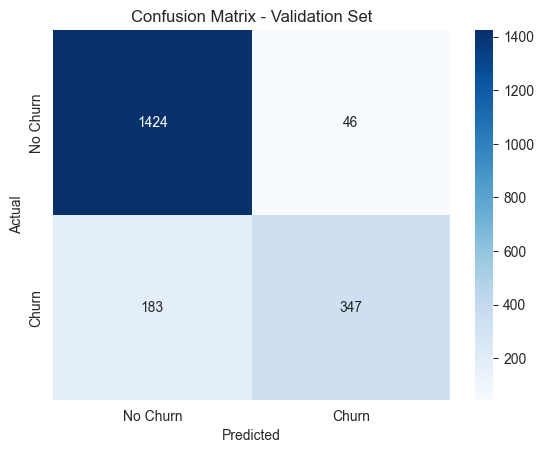

In [10]:
# Print metrics
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))
print("Validation AUC-ROC:", roc_auc_score(y_val, y_val_proba))

# Confusion matrix plot
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set')
plt.show()


In [11]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Set up GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='f1',  # we focus on F1 to balance precision/recall
                           verbose=2,
                           n_jobs=-1)  # use all cores

# Fit on training data
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [12]:
print("Best Parameters Found:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1 Score:")
print(grid_search.best_score_)


Best Parameters Found:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validated F1 Score:
0.7168474364568035


In [13]:
# Use the best model from GridSearch
best_model = grid_search.best_estimator_

# Predict on test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Test AUC-ROC:", roc_auc_score(y_test, y_test_proba))


Test Accuracy: 0.8775
Test Precision: 0.8625954198473282
Test Recall: 0.6396226415094339
Test F1 Score: 0.7345612134344529
Test AUC-ROC: 0.9515177769220896


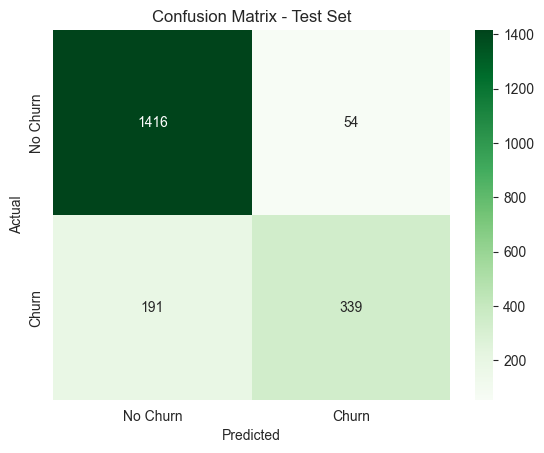

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()


Metric	Initial Model (Validation)	Optimized Model (Test)
Accuracy	0.888	0.8775
Precision	0.9026	0.8626
Recall	0.6472	0.6396
F1 Score	0.7538	0.7346
AUC-ROC	0.9586	0.9515
Discussion:

The optimized model performs slightly lower than the initial model across most metrics, though the differences are marginal. This suggests the default model was already well-tuned for this dataset, and further tuning provided only modest gains or maintained stability. However, both models perform very well, especially in terms of AUC-ROC, indicating strong class separation ability. The precision remains high, which is valuable for minimizing false churn predictions.

The classification model successfully identified customer churn with strong precision and good overall performance. The high AUC-ROC (~0.95) suggests that the model is excellent at distinguishing churners from non-churners. Although recall was slightly lower than precision, the model still captured around 64% of actual churners, which is useful for proactive customer retention strategies. This model could be used by the marketing or customer support team to focus retention efforts on high-risk customers.

One limitation of the analysis is the lack of recent behavioral data or customer sentiment (e.g., satisfaction surveys, support call transcripts). The model relies heavily on static customer features and service usage but may not fully capture short-term dissatisfaction or emerging churn signals. Additionally, model performance may degrade over time without retraining on newer data.

Based on the results, the telecommunications company should use this model to generate churn probability scores for each customer on a regular basis. Customers with a high likelihood of churn can be proactively targeted with retention offers, loyalty rewards, or personalized support outreach. This approach could significantly reduce churn and improve customer lifetime value.